# `kNNpy.Auxiliary.constructingFishermatrix` Tutorial: A quick way to forecast errors from simulations by constructing a Fisher matrix from the data vectors and the fulll covariance matrix from N-body simulations.

**Author**: Anargha Mondal\
**Date**: 3 June 2026\
**kNNpy version**: 0.0.1

#### This notebook presents a simple guide on how to use the `constructingFishermatrix` function to calculate the Fisher information matrix out of given set of data vectors, a covariance matrix, and the parameters of the hyperspace. The basic functionalities of the module are illustrated using realistic cosmological N-body simulations, taken from [QUIJOTE simulations](https://quijote-simulations.readthedocs.io/en/latest/). A detailed API [documentation](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/Auxiliary/Fisher.html) and source code for the module is available on the `kNNpy` [website](https://kitnenikatnivasi.github.io/).

## A brief introduction to Fisher matrices

Sometimes, it is useful to forecast the uncertainty of an experiment before taking any physical measurements. One way to do this is to calculate the Fisher information:
$$F_{ij}=\left\lang \frac{\partial^2\mathcal{L}}{\partial\theta_i\partial\theta_j}\right\rang$$
where $\mathcal{L}\equiv -\text{ln} L$, where $L$ is the likelihood fuction

For an $n$-dimesional parameter space, the above quantity can be represented as an $n\times n$ matrix. Fisher matrices are used frequently in the analysis of combining cosmological constraints from various data sets. They encode the Gaussian uncertainties of multiple variables.

For a Gaussian liklihood, and given cosmological parameters $\vec{{\theta}}$ and given a statistic $\vec{S}$, the Fisher matrix is defined as:
$$ F_{ij}=\displaystyle\Sigma_{\alpha,\beta}\frac{\partial S_\alpha}{\partial \theta_i}C^{-1}_{\alpha\beta}\frac{\partial S_{\beta}}{\partial \theta_j} $$
The trace term has been dropped, as it is expected to be small [Kodwani et al. 2019](https://astro.theoj.org/article/7716-the-effect-on-cosmological-parameter-estimation-of-a-parameter-dependent-covariance-matrix). 

For more information, see [Tegmark et al. 1997](https://iopscience.iop.org/article/10.1086/303939)

<!--TABLE OF CONTENTS-->
# Contents:
- [Imports and Setup](#Imports-and-Setup)
- [Data Vectors and Covariance Matrix](#Data-Vectors-and-Covariance-Matrix)
  - [Data Vectors](#Data-Vectors)
  - [Computing the Covariance Matrix](#Computing-the-Covariance-Matrix)
- [Corner Plots](#Corner-Plots)
    

# Imports and Setup

#### Let's start by importing the required Python libraries. These should already be present in the `kNNpy_env` virtual environment created during the [installation](https://kitnenikatnivasi.github.io/install.html), so you should be able to import them without any issues.

In [2]:
#Importing external libraries

import numpy as np
import readgadget
import readfof

from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors
from getdist import plots, MCSamples

import os
import sys

import warnings
import plotting_library as PL
from pylab import *
from matplotlib.colors import LogNorm
#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

import MAS_library as MASL

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('../'))           # '../' is needed because the parent directory is one directories upstream of the tutorials directory
if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy.Auxiliary import Fisher as f         

#### We define our `matplotlib` plotting preferences below; you can change them to your liking. Remember to set `ustex==False` if you do not have $\LaTeX$ installed. 

In [33]:
#Matplotlib settings

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=True)
plt.rcParams.update({'font.size': 18})
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
BrightColors = ['cyan', 'yellow', 'lime', 'pink', '#E0B0FF']

g = plots.get_subplot_plotter(width_inch=10)
g.settings.linewidth = 1
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 18
g.settings.alpha_filled_add = 0.7
plt.figure(dpi=400)



<Figure size 2560x1920 with 0 Axes>

<Figure size 2560x1920 with 0 Axes>

# Data Vectors and the Covariance Matrix

## Data Vectors

We will be comparing the Fisher constraints between kNN CDFs (calculated using [kNNpy.kNN_3D.TracerFieldCross3D](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/kNN_3D.html#TracerFieldCross3D)) and the two-point cross correlation function (calculated using [kNNpy.Auxilliary.TPCF.TracerField3D.CrossCorr2pt](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/Auxiliary/TPCF/3DTPCF_Tracer-Field.html#CrossCorr2pt)) for $10^5$ most massive halos cross-correlated with the total matter field. We have combined the constraints for k=1,2,3,4.

### Defining the parameters 

In [4]:

mean = np.array([0.3175, 0.6711, 0.834, 0])
num_params=4
dtheta = [0.01, 0.02, 0.01, 0.2]
custom_cet = ["#F48D69","k","#A8198F", "#90EE90"]
labels = [ r'$\Omega_m$',r'$h$', r'$\sigma_8$', r'$M_{\nu}$']  

box=1000 #Mpc/h


In [5]:
path = '../kNNpy/Data/Quijote_simulations/'

In [15]:
no_bins=7
r_min_1, r_max_1 = 7.34,  25.54
r_min_2, r_max_2 = 10.78, 28.11
r_min_3, r_max_3 = 13.06, 30.94
r_min_4, r_max_4 = 15.82, 34.06

binrad2PCF= np.logspace(np.log10(r_min_1), np.log10(r_max_4), no_bins)
binrad1NN= np.logspace(np.log10(r_min_1), np.log10(r_max_1), no_bins)
binrad2NN= np.logspace(np.log10(r_min_2), np.log10(r_max_2), no_bins)
binrad3NN= np.logspace(np.log10(r_min_3), np.log10(r_max_3), no_bins)
binrad4NN= np.logspace(np.log10(r_min_4), np.log10(r_max_4), no_bins)

### Loading the data vectors

2PCF

In [6]:
D_fid_tpcf=np.load(f'{path}/2PCFs/Meandatavecs/averaged_2PCF_fiducial_ZA.npy')
D_Mnu_pp_tpcf=np.load(f'{path}/2PCFs/Meandatavecs/averaged_2PCF_Mnu_pp.npy')
D_Om_p_tpcf=np.load(f'{path}/2PCFs/Meandatavecs/averaged_2PCF_Om_p.npy')
D_Om_m_tpcf=np.load(f'{path}/2PCFs/Meandatavecs/averaged_2PCF_Om_m.npy')
D_h_p_tpcf=np.load(f'{path}/2PCFs/Meandatavecs/averaged_2PCF_h_p.npy')
D_h_m_tpcf=np.load(f'{path}/2PCFs/Meandatavecs/averaged_2PCF_h_m.npy')
D_s8_p_tpcf=np.load(f'{path}/2PCFs/Meandatavecs/averaged_2PCF_s8_p.npy')
D_s8_m_tpcf=np.load(f'{path}/2PCFs/Meandatavecs/averaged_2PCF_s8_m.npy')
D_Mnu_ppp_tpcf=np.load(f'{path}/2PCFs/Meandatavecs/averaged_2PCF_Mnu_ppp.npy')

Text(0, 0.5, '$\\xi(r)$')

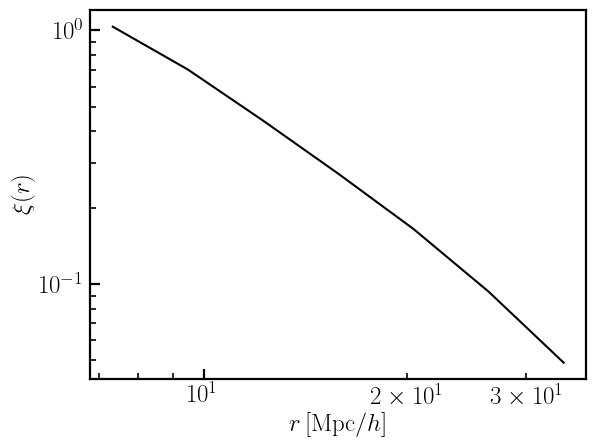

In [27]:
plt.plot(binrad2PCF, D_fid_tpcf, label='Fiducial', color='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$r \, [\mathrm{Mpc}/h]$')
plt.ylabel(r'$\xi(r)$')

1,2,3,4-NN CDFs combined

In [28]:
D_fid_kNN=np.load(f'{path}/kNN-CDFs/Combineddatavecs/datavec_fid_ZA.npy')
D_Mnu_pp_kNN=np.load(f'{path}/kNN-CDFs/Combineddatavecs/datavec_Mnu_pp.npy')
D_Om_p_kNN=np.load(f'{path}/kNN-CDFs/Combineddatavecs/datavec_Om_p.npy')
D_Om_m_kNN=np.load(f'{path}/kNN-CDFs/Combineddatavecs/datavec_Om_m.npy')
D_h_p_kNN=np.load(f'{path}/kNN-CDFs/Combineddatavecs/datavec_h_p.npy')
D_h_m_kNN=np.load(f'{path}/kNN-CDFs/Combineddatavecs/datavec_h_m.npy')
D_s8_p_kNN=np.load(f'{path}/kNN-CDFs/Combineddatavecs/datavec_s8_p.npy')
D_s8_m_kNN=np.load(f'{path}/kNN-CDFs/Combineddatavecs/datavec_s8_m.npy')
D_Mnu_ppp_kNN=np.load(f'{path}/kNN-CDFs/Combineddatavecs/datavec_Mnu_ppp.npy')

Text(0, 0.5, '$CDF(r)$')

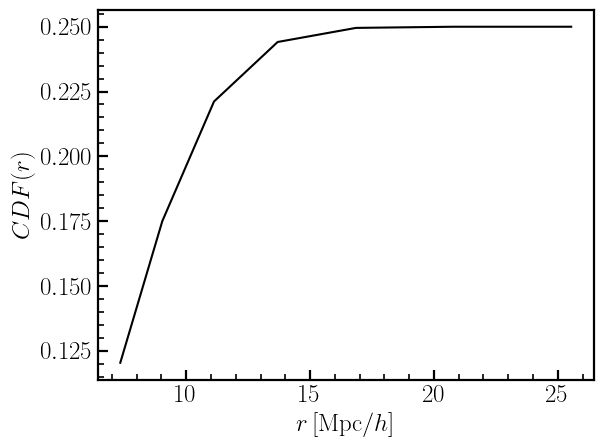

In [30]:
plt.plot(binrad1NN, D_fid_kNN[:7], label='Fiducial', color='k')
plt.xlabel(r'$r \, [\mathrm{Mpc}/h]$')
plt.ylabel(r'$CDF(r)$')

### Calculating the derivatives

2PCF

In [31]:
#Derivatives
n=100
p=len(D_fid_tpcf) #length of data vector
# Calculating the derivatives of the data vector with respect to the 4 parameters
d_tpcf = np.zeros([4,p])
d_f=D_fid_tpcf

d0_p = D_Om_p_tpcf 
d0_m = D_Om_m_tpcf
del0 = d0_p - d0_m
d_tpcf[0] = del0/(2*dtheta[0]) # the partial derivative of data vector with respect to Om

d1_p = D_h_p_tpcf
d1_m = D_h_m_tpcf
del1 = d1_p - d1_m
d_tpcf[1] = del1/(2*dtheta[1]) # the partial derivative of data vector with respect to h

d2_p = D_s8_p_tpcf
d2_m = D_s8_m_tpcf
del2 = d2_p - d2_m
d_tpcf[2] = del2/(2*dtheta[2]) # the partial derivative of data vector with respect to s8

d_tpcf[3] = (4*D_Mnu_pp_tpcf-3*D_fid_tpcf-D_Mnu_ppp_tpcf)/(2*dtheta[3])
print(d_tpcf.shape)

(4, 7)


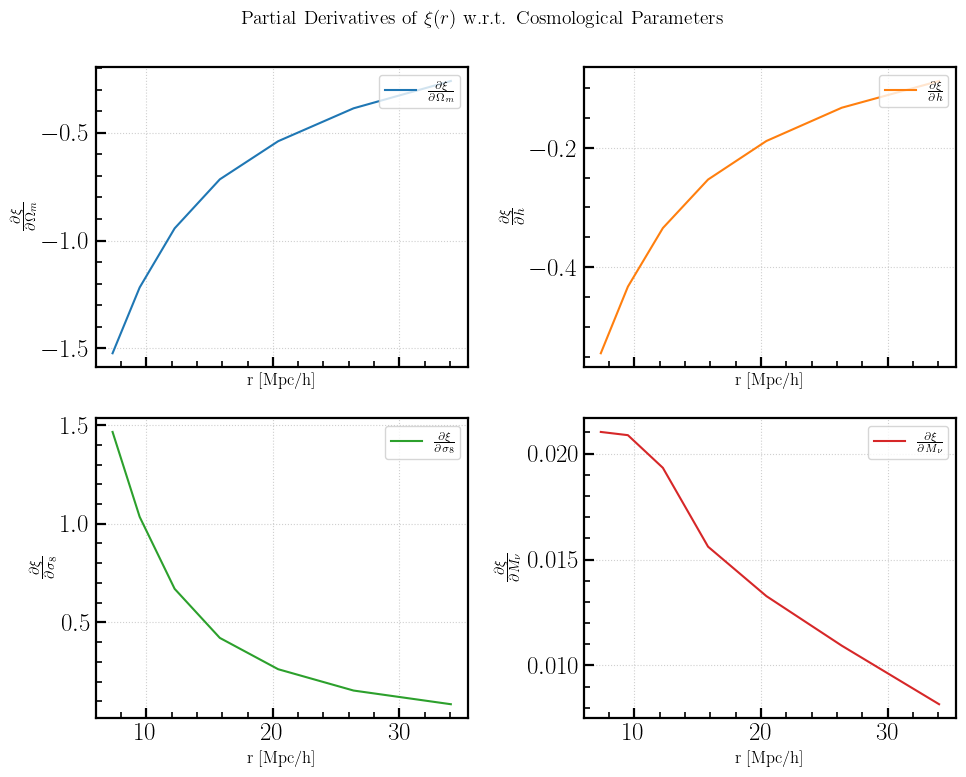

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes=axes.flatten()
# Labels for each parameter derivative using LaTeX formatting
labels = [
    r'$\frac{\partial \xi}{\partial \Omega_m}$',
    r'$\frac{\partial \xi}{\partial h}$',
    r'$\frac{\partial \xi}{\partial \sigma_8}$',
    r'$\frac{\partial \xi}{\partial M_\nu}$'
]

# Distinct colors for each plot
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(4):
    # Plot the derivative data
    axes[i].plot(binrad2PCF, d_tpcf[i], color=colors[i], label=labels[i])
    axes[i].set_ylabel(labels[i], fontsize=14)
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend(loc='upper right', fontsize=11)
    axes[i].set_xlabel('r [Mpc/h]', fontsize=12)
# Figure title
fig.suptitle(r'Partial Derivatives of $\xi(r)$ w.r.t. Cosmological Parameters', fontsize=14, y=0.98)

# Adjust layout to avoid overlapping labels
plt.tight_layout()

1,2,3,4-NN CDFs combined

In [52]:
#Derivatives
n=100
p=len(D_fid_kNN) #length of data vector
# Calculating the derivatives of the data vector with respect to the 4 parameters
d_kNN = np.zeros([4,p])
d_f=D_fid_kNN

d0_p = D_Om_p_kNN   
d0_m = D_Om_m_kNN
del0 = d0_p - d0_m
d_kNN[0] = del0/(2*dtheta[0]) # the partial derivative of data vector with respect to Om

d1_p = D_h_p_kNN
d1_m = D_h_m_kNN
del1 = d1_p - d1_m
d_kNN[1] = del1/(2*dtheta[1]) # the partial derivative of data vector with respect to h

d2_p = D_s8_p_kNN
d2_m = D_s8_m_kNN
del2 = d2_p - d2_m
d_kNN[2] = del2/(2*dtheta[2]) # the partial derivative of data vector with respect to s8

d_kNN[3] = (4*D_Mnu_pp_kNN-3*D_fid_kNN-D_Mnu_ppp_kNN)/(2*dtheta[3])
print(d_kNN.shape)

(4, 28)


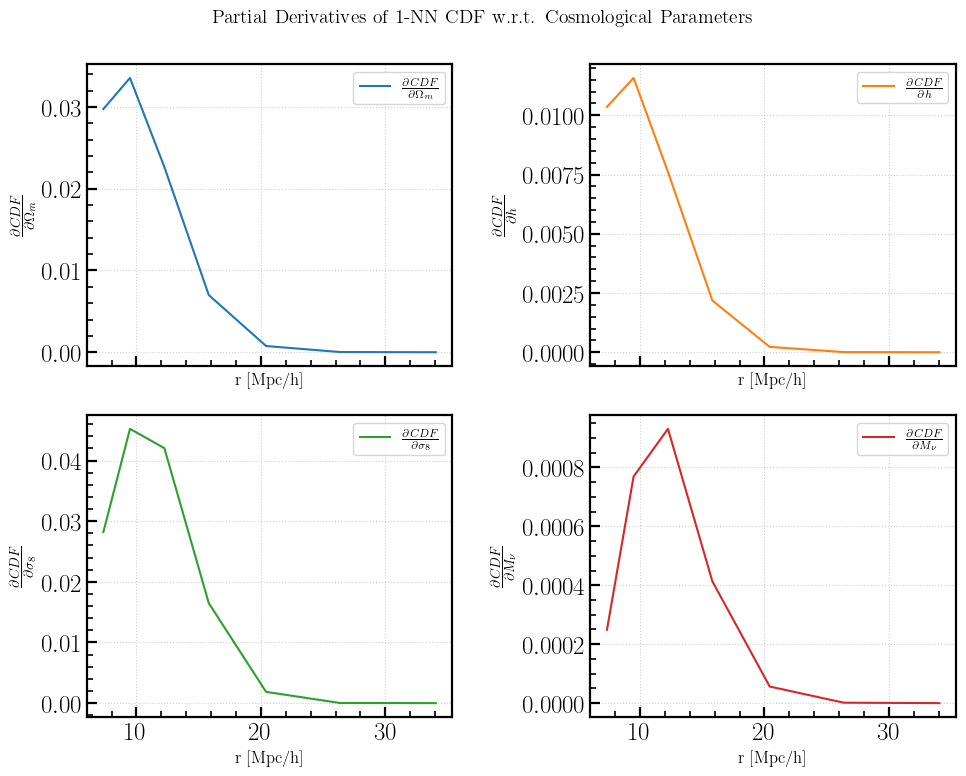

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes=axes.flatten()
# Labels for each parameter derivative using LaTeX formatting
labels = [
    r'$\frac{\partial CDF}{\partial \Omega_m}$',
    r'$\frac{\partial CDF}{\partial h}$',
    r'$\frac{\partial CDF}{\partial \sigma_8}$',
    r'$\frac{\partial CDF}{\partial M_\nu}$'
]

# Distinct colors for each plot
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(4):
    # Plot the derivative data
    axes[i].plot(binrad2PCF, d_kNN[i][:7], color=colors[i], label=labels[i])
    axes[i].set_ylabel(labels[i], fontsize=14)
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend(loc='upper right', fontsize=11)
    axes[i].set_xlabel('r [Mpc/h]', fontsize=12)
# Figure title
fig.suptitle('Partial Derivatives of 1-NN CDF w.r.t. Cosmological Parameters', fontsize=14, y=0.98)

# Adjust layout to avoid overlapping labels
plt.tight_layout()

### Calculating the Covariance Matrix

2PCF

In [49]:
n_cov=1000
fid_datavecs=[]
for i in range(n_cov):
    iteration=np.load(f'{path}/2PCFs/fiducial_2LPT/{i}/twoPCF_fid2LPT_{i}.npy')
    fid_datavecs.append(iteration)
cov_tpcf = np.cov(fid_datavecs, rowvar=False, ddof=1)
del fid_datavecs

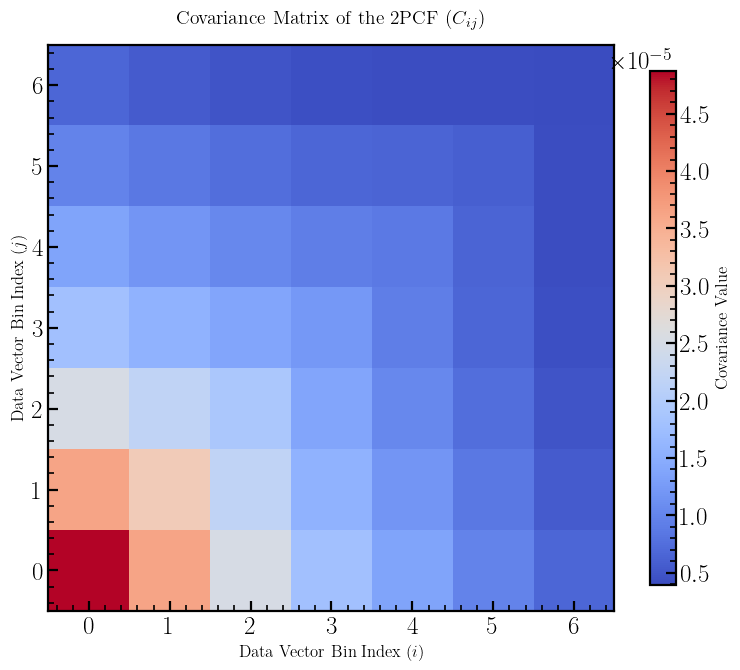

In [56]:
fig, ax = plt.subplots(figsize=(8, 7))

# Plot the matrix (Change cov_tpcf to corr_tpcf if you want to plot the correlation matrix instead)
# 'coolwarm' or 'viridis' work well for matrices; 'lower' matches the usual standard orientation
im = ax.imshow(cov_tpcf, cmap='coolwarm', origin='lower')

# Add a colorbar to show scale
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Covariance Value', fontsize=12)
# If plotting correlation matrix, use: cbar.set_label(r'Correlation Coefficient $R_{ij}$', fontsize=12)

# Labels and Title using LaTeX formatting
ax.set_title('Covariance Matrix of the 2PCF ($C_{ij}$)', fontsize=14, pad=15)
ax.set_xlabel('Data Vector Bin Index ($i$)', fontsize=12)
ax.set_ylabel('Data Vector Bin Index ($j$)', fontsize=12)

# Ensure grid lines are off for clean pixel representation
ax.grid(False)

# Optimize spacing and display
plt.tight_layout()
plt.show()

1,2,3,4-NN CDFs combined

In [13]:
fid_datavecs=[]
for i in range(1000):
    iteration=np.load(f'{path}/kNN-CDFs/Combineddatavecs/fiducial_2LPT/{i}/datavec_fid_{i}.npy')
    fid_datavecs.append(iteration)
cov_kNN = np.cov(fid_datavecs, rowvar=False, ddof=1)
del fid_datavecs

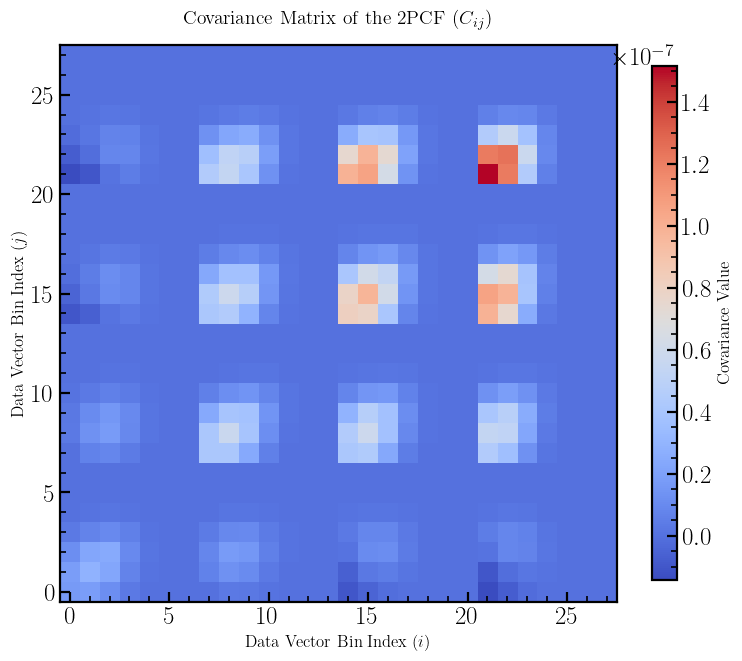

In [57]:
fig, ax = plt.subplots(figsize=(8, 7))

# Plot the matrix (Change cov_tpcf to corr_tpcf if you want to plot the correlation matrix instead)
# 'coolwarm' or 'viridis' work well for matrices; 'lower' matches the usual standard orientation
im = ax.imshow(cov_kNN, cmap='coolwarm', origin='lower')

# Add a colorbar to show scale
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Covariance Value', fontsize=12)
# If plotting correlation matrix, use: cbar.set_label(r'Correlation Coefficient $R_{ij}$', fontsize=12)

# Labels and Title using LaTeX formatting
ax.set_title('Covariance Matrix of the 2PCF ($C_{ij}$)', fontsize=14, pad=15)
ax.set_xlabel('Data Vector Bin Index ($i$)', fontsize=12)
ax.set_ylabel('Data Vector Bin Index ($j$)', fontsize=12)

# Ensure grid lines are off for clean pixel representation
ax.grid(False)

# Optimize spacing and display
plt.tight_layout()
plt.show()

### Plotting...

In [15]:
F_2PCF, gauss_2PCF=f.constructingFishermatrix(cov_tpcf, d_tpcf, n_cov, mean, labels)
F_kNN, gauss_kNN=f.constructingFishermatrix(cov_kNN, d_kNN, n_cov, mean, labels)

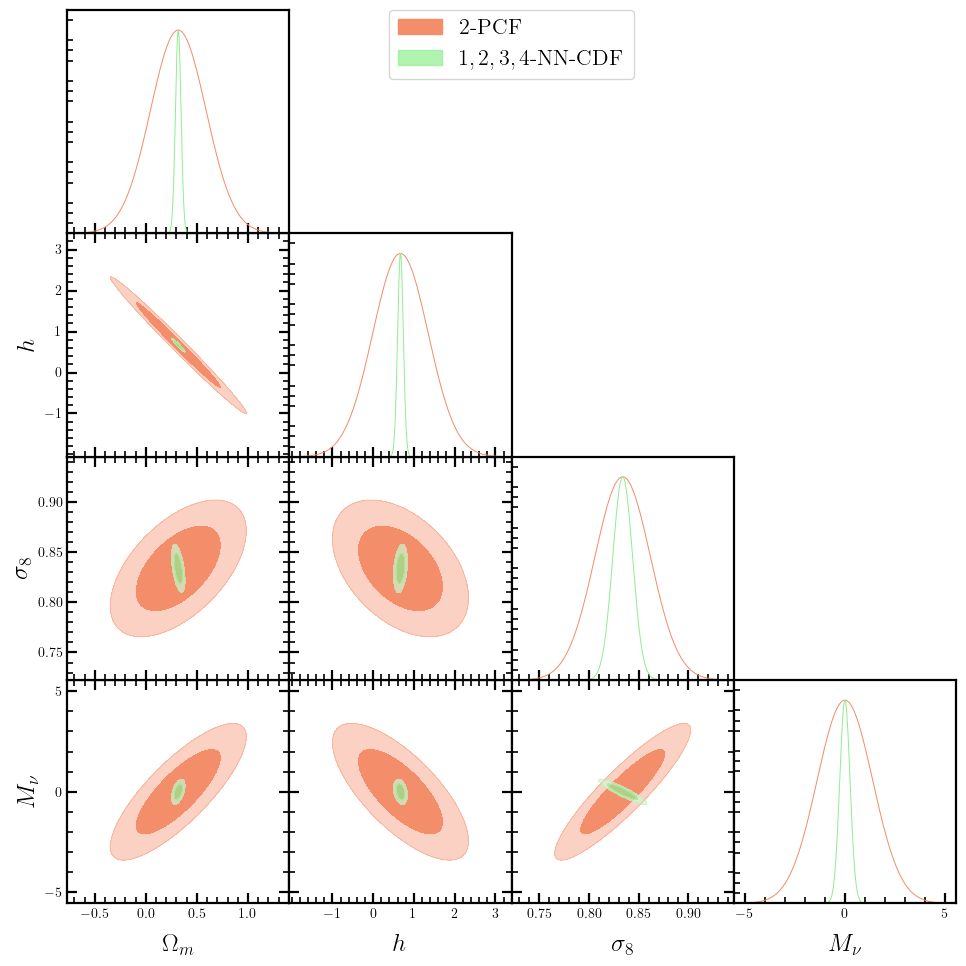

In [16]:
g.triangle_plot([gauss_2PCF, gauss_kNN], filled=[True, True],
    line_args=[{'color': custom_cet[0]}, {'color': custom_cet[3]}],
    contour_colors=[custom_cet[0], custom_cet[3]], contour_ls = ['-','-'], legend_labels=[r'$2$-PCF', r'$1,2,3,4$-NN-CDF'])
